In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv(r"D:\ML\Scikit-Learn-Tutorial-\New ML\titanic_toy.csv")
df.head()

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0


In [4]:
X= df.drop(columns=['Survived'])
y = df['Survived']

In [5]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.02, random_state=42)

In [6]:
age_mean = X_train['Age'].mean()
age_median = X_train['Age'].median()

fare_mean = X_train['Fare'].mean()
fare_median = X_train['Fare'].median()

In [10]:
fare_median
fare_mean

np.float64(32.46998707729468)

In [7]:
X_train['Age_Mean'] = X_train['Age'].fillna(age_mean)
X_train['Age_median'] = X_train['Age'].fillna(age_median)

X_train['Fare_Mean'] = X_train['Fare'].fillna(fare_mean)
X_train['Fare_median'] = X_train['Fare'].fillna(fare_median)

In [8]:
X_train.sample(6)

,Age,Fare,Family,Age_Mean,Age_median,Fare_Mean,Fare_median
217,42.0,27.0000,1,42.000000,42.0,27.0000,27.0000
42,NaN,7.8958,0,29.788814,28.0,7.8958,7.8958
473,23.0,13.7917,0,23.000000,23.0,13.7917,13.7917
409,NaN,25.4667,4,29.788814,28.0,25.4667,25.4667
302,19.0,0.0000,0,19.000000,19.0,0.0000,0.0000
342,28.0,13.0000,0,28.000000,28.0,13.0000,13.0000


In [13]:
print('Original Age variable variance: ', X_train['Age'].var())
print('Age Variance after median imputation: ', X_train['Age_median'].var())
print('Age Variance after mean imputation: ', X_train['Age_Mean'].var())

print('Original Fare variable variance: ', X_train['Fare'].var())
print('Fare Variance after median imputation: ', X_train['Fare_median'].var())
print('Fare Variance after mean imputation: ', X_train['Fare_Mean'].var())

Original Age variable variance:  212.31338328448805
Age Variance after median imputation:  170.70060737728176
Age Variance after mean imputation:  170.1915767383683
Original Fare variable variance:  2575.3928830183213
Fare Variance after median imputation:  2458.3745817254617
Fare Variance after mean imputation:  2442.4884337799904


<Axes: ylabel='Density'>

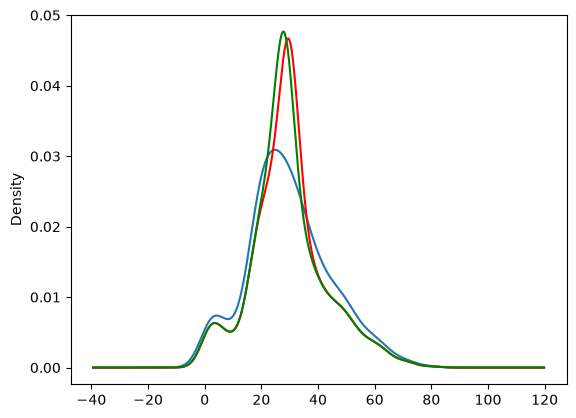

In [14]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Age'].plot(kind='kde', ax=ax)

X_train['Age_Mean'].plot(kind='kde', ax=ax, color='red')

X_train['Age_median'].plot(kind='kde', ax=ax ,color = 'green')

<Axes: ylabel='Density'>

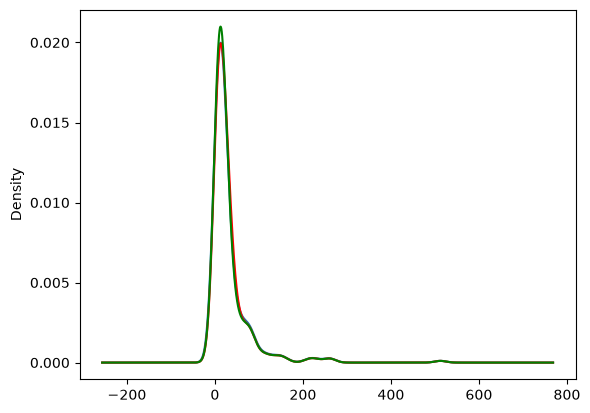

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111)

X_train['Fare'].plot(kind='kde',ax=ax)

X_train['Fare_Mean'].plot(kind='kde',ax=ax , color='red')

X_train['Fare_median'].plot(kind='kde', ax=ax , color='green')

In [16]:
X_train.cov()

,Age,Fare,Family,Age_Mean,Age_median,Fare_Mean,Fare_median
Age,212.313383,78.311199,-6.605467,212.313383,212.313383,73.879802,73.422674
Fare,78.311199,2575.392883,17.756479,62.444959,65.944351,2575.392883,2575.392883
Family,-6.605467,17.756479,2.633369,-5.294979,-5.231898,16.840147,16.876781
Age_Mean,212.313383,62.444959,-5.294979,170.191577,170.191577,59.222456,58.856019
Age_median,212.313383,65.944351,-5.231898,170.191577,170.700607,62.541260,62.066999
Fare_Mean,73.879802,2575.392883,16.840147,59.222456,62.541260,2442.488434,2442.488434
Fare_median,73.422674,2575.392883,16.876781,58.856019,62.066999,2442.488434,2458.374582


In [18]:
X_train.var

<bound method DataFrame.var of       Age      Fare  Family   Age_Mean  Age_median   Fare_Mean  Fare_median
886  27.0   13.0000       0  27.000000        27.0   13.000000      13.0000
110  47.0   52.0000       0  47.000000        47.0   52.000000      52.0000
294  24.0    7.8958       0  24.000000        24.0    7.895800       7.8958
447  34.0   26.5500       0  34.000000        34.0   26.550000      26.5500
192  19.0    7.8542       1  19.000000        19.0    7.854200       7.8542
..    ...       ...     ...        ...         ...         ...          ...
106  21.0    7.6500       0  21.000000        21.0    7.650000       7.6500
270   NaN   31.0000       0  29.788814        28.0   31.000000      31.0000
860  41.0       NaN       2  41.000000        41.0   32.469987      14.4542
435  14.0  120.0000       3  14.000000        14.0  120.000000     120.0000
102  21.0   77.2875       1  21.000000        21.0   77.287500      77.2875

[873 rows x 7 columns]>

<Axes: >

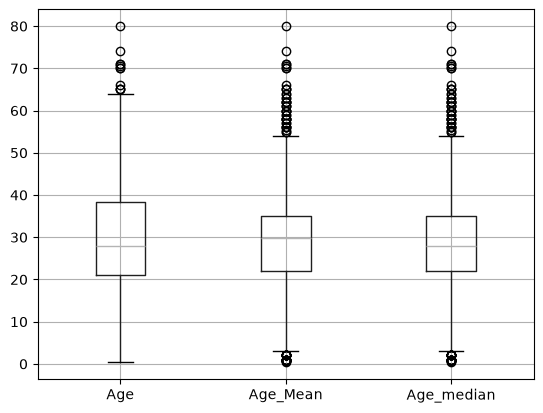

In [20]:
X_train[['Age','Age_Mean','Age_median']].boxplot()

<Axes: >

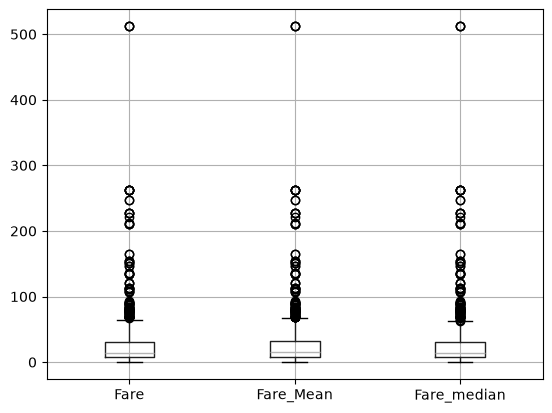

In [21]:
X_train[['Fare','Fare_Mean','Fare_median']].boxplot()

In [22]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer

X_train, X_test, y_train, y_test = train_test_split(X,y , test_size=0.02, random_state=42)

In [23]:
imput1 = SimpleImputer(strategy="mean")
imput2 = SimpleImputer(strategy='median')


In [24]:
trf = ColumnTransformer([
    ('imput1',imput2,['Fare']),
    ('imput2', imput1,['Age'])
], remainder='passthrough')

In [25]:
trf.fit(X_train)

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('imput1', ...), ('imput2', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``f

In [26]:
trf.named_transformers_["imput1"].statistics_

array([14.4542])

In [27]:
trf.named_transformers_['imput2'].statistics_

array([29.78881429])

In [30]:
X_train = trf.transform(X_train)
X_test = trf.transform(X_test)

In [31]:
X_train

array([[ 13.    ,  27.    ,   0.    ],
       [ 52.    ,  47.    ,   0.    ],
       [  7.8958,  24.    ,   0.    ],
       ...,
       [ 14.4542,  41.    ,   2.    ],
       [120.    ,  14.    ,   3.    ],
       [ 77.2875,  21.    ,   1.    ]], shape=(873, 3))